<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/April2026/3aprilConvNeXtSSL_Hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import convnext_tiny
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

data_dir = "/content/drive/MyDrive/ResearchData/April26/1AprilreshuffledDataset"

full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# IMPORTANT: apply val transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
num_classes = len(full_dataset.classes)
print("Classes:", full_dataset.classes)


Classes: ['0', '1', '2', '3', '4', '5']


In [17]:
class HybridConvNeXt(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        backbone = convnext_tiny(pretrained=True)

        # ONLY feature extractor (IMPORTANT)
        self.features = backbone.features

        # Pool + Flatten
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Heads
        self.classifier = nn.Linear(768, num_classes)
        self.rotation_head = nn.Linear(768, 4)

    def forward(self, x):
        x = self.features(x)        # [B, 768, H, W]
        x = self.pool(x)            # [B, 768, 1, 1]
        x = torch.flatten(x, 1)     # [B, 768]

        class_out = self.classifier(x)
        rot_out = self.rotation_head(x)

        return class_out, rot_out

In [18]:
def rotate_batch(images):
    B = images.size(0)
    rot_labels = torch.randint(0, 4, (B,))
    rotated = []

    for i in range(B):
        angle = int(rot_labels[i]) * 90
        rotated.append(TF.rotate(images[i], angle))

    return torch.stack(rotated), rot_labels

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = HybridConvNeXt(num_classes).to(device)

criterion_cls = nn.CrossEntropyLoss()
criterion_rot = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [20]:
x = torch.randn(2, 3, 224, 224).to(device)
c, r = model(x)

print("Class output:", c.shape)   # [2, num_classes]
print("Rotation output:", r.shape)  # [2, 4]

Class output: torch.Size([2, 6])
Rotation output: torch.Size([2, 4])


In [21]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs, _ = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return correct / total, all_labels, all_preds

In [22]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # SSL rotation
        rot_images, rot_labels = rotate_batch(images)
        rot_images = rot_images.to(device)
        rot_labels = rot_labels.to(device)

        # Forward
        class_out, _ = model(images)
        _, rot_out = model(rot_images)

        # Loss
        loss_cls = criterion_cls(class_out, labels)
        loss_rot = criterion_rot(rot_out, rot_labels)

        loss = loss_cls + 0.5 * loss_rot

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    val_acc, y_true, y_pred = evaluate(model, val_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Loss: {total_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")


Epoch 1
Loss: 55.1703
Val Accuracy: 0.5580

Epoch 2
Loss: 41.0166
Val Accuracy: 0.7143

Epoch 3
Loss: 32.9042
Val Accuracy: 0.7768

Epoch 4
Loss: 26.8546
Val Accuracy: 0.7054

Epoch 5
Loss: 22.9773
Val Accuracy: 0.8036

Epoch 6
Loss: 21.2765
Val Accuracy: 0.7768

Epoch 7
Loss: 20.2143
Val Accuracy: 0.7321

Epoch 8
Loss: 23.4282
Val Accuracy: 0.7634

Epoch 9
Loss: 19.6495
Val Accuracy: 0.7411

Epoch 10
Loss: 18.2348
Val Accuracy: 0.7902


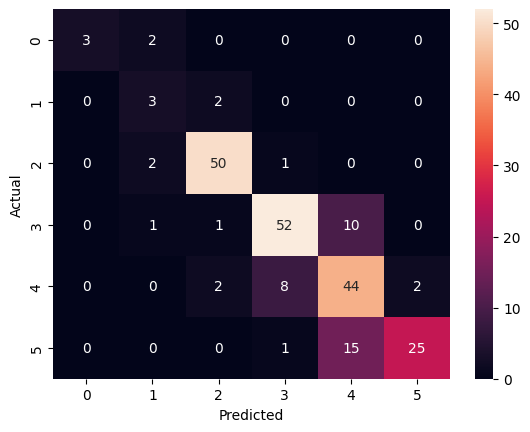

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
